# Batched Deep CFR GPU Validation

This notebook checks the batched Deep CFR traversal backend before using it for long GPU runs.

In [1]:
from pathlib import Path
import random
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / 'liars_poker').exists() and REPO_ROOT.parent != REPO_ROOT:
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from liars_poker.algo.br_exact_dense_to_dense import best_response_dense
from liars_poker.algo.deep_cfr import DeepCFRTrainer
from liars_poker.algo.deep_cfr_diagnostics import ExactDenseStrategyAverager
from liars_poker.algo.neural_cfr_batched import BatchedDeepCFRTraverser
from liars_poker.core import GameSpec, card_rank, generate_deck
from liars_poker.env import resolve_call_winner, rules_for_spec
from liars_poker.infoset import CALL
from liars_poker.policies.neural import compile_neural_to_dense
from liars_poker.training.deep_cfr import deep_cfr_loop, deep_cfr_timed_loop

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('torch', torch.__version__)
print('device', device)
if torch.cuda.is_available():
    print('gpu', torch.cuda.get_device_name(0))

torch 2.12.0+cpu
device cpu


In [2]:
spec = GameSpec(
    ranks=4,
    suits=4,
    hand_size=3,
    claim_kinds=('RankHigh', 'Pair', 'Trips'),
    suit_symmetry=True,
)
rules = rules_for_spec(spec)
print(spec.to_short_str())
print('claims', len(rules.claims))

r4_s4_h3_hpt_ss
claims 12


## Static Correctness Checks

In [3]:
def hand_counts(hand, spec):
    counts = np.zeros(spec.ranks, dtype=np.float32)
    for card in hand:
        counts[card_rank(card, spec) - 1] += 1.0
    return counts

trainer = DeepCFRTrainer(
    spec,
    hidden_sizes=(16,),
    device=device,
    seed=11,
    traversal_backend='batched',
    traversal_batch_size=8,
)
runner = BatchedDeepCFRTraverser(trainer)

deck = list(generate_deck(spec))
rng = random.Random(123)
p1_hands = []
p2_hands = []
for _ in range(12):
    rng.shuffle(deck)
    p1_hands.append(tuple(sorted(deck[:spec.hand_size])))
    p2_hands.append(tuple(sorted(deck[spec.hand_size:2 * spec.hand_size])))

p1_counts = torch.as_tensor(np.stack([hand_counts(h, spec) for h in p1_hands]), device=device)
p2_counts = torch.as_tensor(np.stack([hand_counts(h, spec) for h in p2_hands]), device=device)
total_counts = p1_counts + p2_counts

claim_ids = [0, min(1, len(rules.claims) - 1), len(rules.claims) - 1]
hids = [1 << claim for claim in claim_ids for _ in range(4)]
deal_ids = list(range(len(hids)))

batched_values = runner._terminal_values(
    hids=hids,
    deal_indices=deal_ids,
    caller=1,
    traverser=0,
    total_counts=total_counts,
)
slow_values = []
for hid, deal_id in zip(hids, deal_ids):
    claim = hid.bit_length() - 1
    winner = resolve_call_winner(spec, (claim, CALL), p1_hands[deal_id], p2_hands[deal_id])
    slow_values.append(1.0 if winner == 'P1' else -1.0)

assert np.allclose(batched_values, np.asarray(slow_values, dtype=np.float32))
print('terminal resolution ok')

terminal resolution ok


In [4]:
history = (0, 2) if len(rules.claims) > 2 else (0,)
hid = sum(1 << action for action in history)
features = runner._features(
    actor=0,
    node_indices=[0],
    deal_indices=[0],
    hids=[hid],
    p1_counts=p1_counts[:1],
    p2_counts=p2_counts[:1],
).detach().cpu().numpy()[0]
expected = trainer.encoder.encode(p1_hands[0], history)
assert np.allclose(features, expected)
print('feature encoding ok')

feature encoding ok


## Smoke Training

In [5]:
def exact_exploitability(policy):
    dense = compile_neural_to_dense(policy)
    _, meta = best_response_dense(spec, dense, debug=False, store_state_values=False)
    p_first, p_second = meta['computer'].exploitability()
    return 0.5 * (p_first + p_second)

def short_run(backend, *, seed=5):
    trainer = DeepCFRTrainer(
        spec,
        hidden_sizes=(32, 32),
        device=device,
        seed=seed,
        batch_size=64,
        advantage_train_steps=5,
        strategy_train_steps=5,
        traversal_backend=backend,
        traversal_batch_size=32,
        validation_fraction=0.05,
    )
    policy, logs, trainer = deep_cfr_loop(
        spec,
        iterations=5,
        trainer=trainer,
        traversals_per_player=32,
        eval_every=5,
        debug=False,
    )
    return policy, logs, trainer

recursive_policy, recursive_logs, recursive_trainer = short_run('recursive', seed=5)
batched_policy, batched_logs, batched_trainer = short_run('batched', seed=5)

pd.DataFrame([
    {
        'backend': 'recursive',
        'advantage records': sum(recursive_logs['training_series'][-1]['advantage_records_seen']),
        'strategy records': sum(recursive_logs['training_series'][-1]['strategy_records_seen']),
        'final exploitability': recursive_logs['exploitability_series'][-1]['predicted_avg'],
    },
    {
        'backend': 'batched',
        'advantage records': sum(batched_logs['training_series'][-1]['advantage_records_seen']),
        'strategy records': sum(batched_logs['training_series'][-1]['strategy_records_seen']),
        'final exploitability': batched_logs['exploitability_series'][-1]['predicted_avg'],
    },
])

,backend,advantage records,strategy records,final exploitability
0,recursive,9235,13955,0.862390
1,batched,2001,12170,0.859097


## Backend Timing

In [6]:
def time_backend(backend, *, traversal_batch_size=128, traversals_per_player=128, seed=19):
    trainer = DeepCFRTrainer(
        spec,
        hidden_sizes=(128, 128),
        device=device,
        seed=seed,
        batch_size=256,
        advantage_train_steps=20,
        strategy_train_steps=20,
        traversal_backend=backend,
        traversal_batch_size=traversal_batch_size,
    )
    record = trainer.run_iteration(traversals_per_player=traversals_per_player)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    timing = record['timing']
    return {
        'backend': backend,
        'traversal batch size': traversal_batch_size if backend == 'batched' else np.nan,
        'traversal s': timing['traversal_s'],
        'fit s': timing['advantage_training_s'] + timing['strategy_training_s'],
        'advantage records': sum(record['new_advantage_records']),
        'strategy records': sum(record['new_strategy_records']),
    }

timing_rows = [time_backend('recursive')]
for batch_size in ([32, 64, 128, 256, 512] if torch.cuda.is_available() else [16, 32, 64]):
    timing_rows.append(time_backend('batched', traversal_batch_size=batch_size))

timing_df = pd.DataFrame(timing_rows)
timing_df['records / traversal s'] = (
    timing_df['advantage records'] + timing_df['strategy records']
) / timing_df['traversal s']
timing_df

,backend,traversal batch size,traversal s,fit s,advantage records,strategy records,records / traversal s
0,recursive,NaN,1.083573,0.360017,272,3144,3152.532168
1,batched,16.0,0.281279,0.449144,256,3031,11685.926937
2,batched,32.0,0.110958,0.369336,266,3108,30407.792476
3,batched,64.0,0.077222,0.347484,290,3093,43808.815881


## Longer GPU Run

Set `RUN_GPU_TRAINING = True` after confirming the timing table. Exact evaluation is intentionally infrequent.

In [15]:
RUN_GPU_TRAINING = True

if RUN_GPU_TRAINING:
    run_spec = GameSpec(
        ranks=4,
        suits=4,
        hand_size=3,
        claim_kinds=('RankHigh', 'Pair', 'Trips'),
        suit_symmetry=True,
    )
    exact_averager = ExactDenseStrategyAverager(run_spec)
    trainer = DeepCFRTrainer(
        run_spec,
        hidden_sizes=(256, 256),
        device=device,
        seed=7,
        batch_size=1024 if torch.cuda.is_available() else 256,
        advantage_train_steps=100,
        strategy_train_steps=50,
        advantage_buffer_capacity=300_000,
        strategy_buffer_capacity=300_000,
        traversal_backend='batched',
        traversal_batch_size=512 if torch.cuda.is_available() else 512,
        validation_fraction=0.02,
        validation_buffer_capacity=20_000,
    )
    policy, logs, trainer = deep_cfr_timed_loop(
        run_spec,
        training_seconds=30*60,
        trainer=trainer,
        traversals_per_player=512,
        eval_every=10,
        exact_averager=exact_averager,
        debug=True,
    )
else:
    logs = {'training_series': [], 'exploitability_series': []}
    trainer = None
    policy = None

[deep-cfr] iter=1 training_budget=2.14/1800.00s traverse=0.37s fit=1.77s
[deep-cfr] iter=2 training_budget=5.48/1800.00s traverse=1.62s fit=1.72s
[deep-cfr] iter=3 training_budget=8.25/1800.00s traverse=1.06s fit=1.70s
[deep-cfr] iter=4 training_budget=11.17/1800.00s traverse=1.19s fit=1.73s
[deep-cfr] iter=5 training_budget=14.00/1800.00s traverse=1.12s fit=1.71s
[deep-cfr] iter=6 training_budget=16.93/1800.00s traverse=1.21s fit=1.72s
[deep-cfr] iter=7 training_budget=19.55/1800.00s traverse=0.91s fit=1.71s
[deep-cfr] iter=8 training_budget=22.33/1800.00s traverse=1.07s fit=1.71s
[deep-cfr] iter=9 training_budget=25.03/1800.00s traverse=0.92s fit=1.78s
[deep-cfr] iter=10 training_budget=27.89/1800.00s traverse=1.14s fit=1.71s
[deep-cfr] iter=11 training_budget=30.83/1800.00s traverse=1.21s fit=1.73s
[deep-cfr] iter=12 training_budget=33.91/1800.00s traverse=1.25s fit=1.83s
[deep-cfr] iter=13 training_budget=37.04/1800.00s traverse=1.27s fit=1.85s
[deep-cfr] iter=14 training_budget=40

,iteration,advantage_loss,strategy_loss,advantage_buffer_sizes,strategy_buffer_sizes,advantage_records_seen,strategy_records_seen,new_advantage_records,new_strategy_records,elapsed_s,timing.traversal_s,timing.advantage_training_s,timing.strategy_training_s,validation.advantage,validation.strategy
558,559,"[0.6217950057983398, 0.6408150508999825]","[0.3620298713445663, 0.394657199382782]","[300000, 300000]","[300000, 300000]","[5876078, 1697421]","[5697854, 18434112]","[11887, 3062]","[10655, 36107]",1787.830660,1.369307,1.056899,0.527983,"[{'records': 2048, 'mse': 0.6188884973526001, ...","[{'records': 2048, 'cross_entropy': 0.37475001..."
559,560,"[0.6243874907493592, 0.6358325588703155]","[0.3660777008533478, 0.40327459692955014]","[300000, 300000]","[300000, 300000]","[5887710, 1700499]","[5708281, 18469849]","[11632, 3078]","[10427, 35737]",1790.988390,1.543011,1.082040,0.531433,"[{'records': 2048, 'mse': 0.6171007752418518, ...","[{'records': 2048, 'cross_entropy': 0.37051296..."
560,561,"[0.6227726101875305, 0.646927524805069]","[0.37309989213943484, 0.39129572570323945]","[300000, 300000]","[300000, 300000]","[5899938, 1702740]","[5716022, 18507173]","[12228, 2241]","[7741, 37324]",1793.883199,1.289263,1.069398,0.534895,"[{'records': 2048, 'mse': 0.6112909317016602, ...","[{'records': 2048, 'cross_entropy': 0.37601128..."
561,562,"[0.6303048315644264, 0.6512969744205475]","[0.36832172095775606, 0.3930702143907547]","[300000, 300000]","[300000, 300000]","[5911993, 1705572]","[5725131, 18545914]","[12055, 2832]","[9109, 38741]",1797.073206,1.570428,1.082395,0.536188,"[{'records': 2048, 'mse': 0.6181417107582092, ...","[{'records': 2048, 'cross_entropy': 0.37262952..."
562,563,"[0.6308766669034958, 0.6408843740820884]","[0.37438233733177184, 0.39693619310855865]","[300000, 300000]","[300000, 300000]","[5924112, 1707865]","[5731974, 18583680]","[12119, 2293]","[6843, 37766]",1800.005860,1.322311,1.078964,0.530352,"[{'records': 2048, 'mse': 0.6167755126953125, ...","[{'records': 2048, 'cross_entropy': 0.37781020..."


,iter,p_first,p_second,predicted_avg,current_p_first,current_p_second,current_predicted_avg,exact_average_p_first,exact_average_p_second,exact_average_predicted_avg,exploitability,exact_average_exploitability,current_exploitability
52,530,0.586268,0.556265,0.571266,0.811396,0.684409,0.747902,0.583944,0.552830,0.568387,0.142532,0.136773,0.495805
53,540,0.588561,0.558136,0.573349,0.854613,0.747889,0.801251,0.583969,0.552649,0.568309,0.146697,0.136618,0.602502
54,550,0.585948,0.551157,0.568553,0.852335,0.766735,0.809535,0.583580,0.551924,0.567752,0.137105,0.135504,0.619070
55,560,0.580658,0.549225,0.564941,0.835205,0.755888,0.795546,0.583712,0.551251,0.567481,0.129882,0.134963,0.591093
56,563,0.583576,0.554107,0.568841,0.842064,0.684650,0.763357,0.583637,0.551218,0.567427,0.137683,0.134854,0.526714


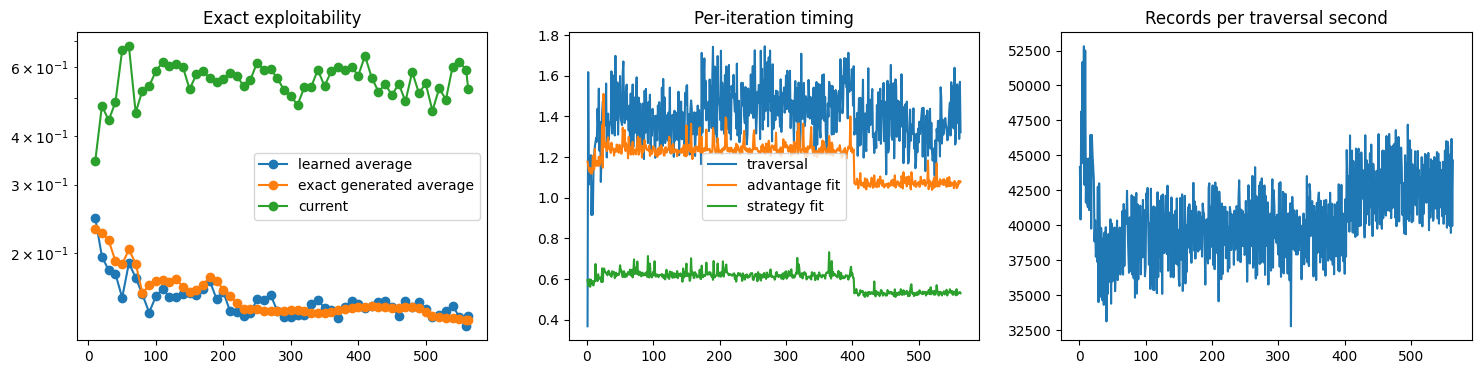

In [17]:
if logs['training_series']:
    train_df = pd.json_normalize(logs['training_series'])
    eval_df = pd.DataFrame(logs['exploitability_series'])
    for col in ['predicted_avg', 'exact_average_predicted_avg', 'current_predicted_avg']:
        if col in eval_df:
            eval_df[col.replace('predicted_avg', 'exploitability')] = (2 * eval_df[col] - 1).clip(lower=1e-8)
    display(train_df.tail())
    display(eval_df.tail())

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    axes[0].plot(eval_df['iter'], eval_df['exploitability'], marker='o', label='learned average')
    if 'exact_average_predicted_avg' in eval_df:
        axes[0].plot(eval_df['iter'], eval_df['exact_average_exploitability'], marker='o', label='exact generated average')
    axes[0].plot(eval_df['iter'], eval_df['current_exploitability'], marker='o', label='current')
    axes[0].set_yscale('log')
    axes[0].set_title('Exact exploitability')
    axes[0].legend()

    axes[1].plot(train_df['iteration'], train_df['timing.traversal_s'], label='traversal')
    axes[1].plot(train_df['iteration'], train_df['timing.advantage_training_s'], label='advantage fit')
    axes[1].plot(train_df['iteration'], train_df['timing.strategy_training_s'], label='strategy fit')
    axes[1].set_title('Per-iteration timing')
    axes[1].legend()

    records = train_df['new_advantage_records'].apply(sum) + train_df['new_strategy_records'].apply(sum)
    axes[2].plot(train_df['iteration'], records / train_df['timing.traversal_s'])
    axes[2].set_title('Records per traversal second')
    plt.show()